In [1]:
import sys 
from pathlib import Path

#Add the project root to the Python path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data import fetch_yahoo
from src.features import add_returns, add_momentum_signal, add_mean_reversion_signal, add_vol_regime
from src.backtest import backtest_long_only, backtest_long_only_with_regime


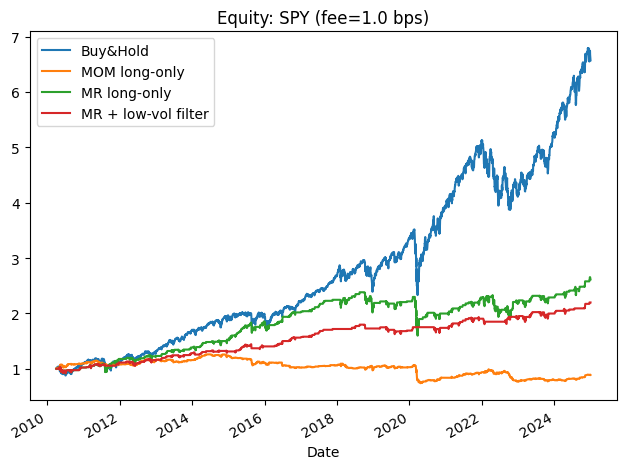

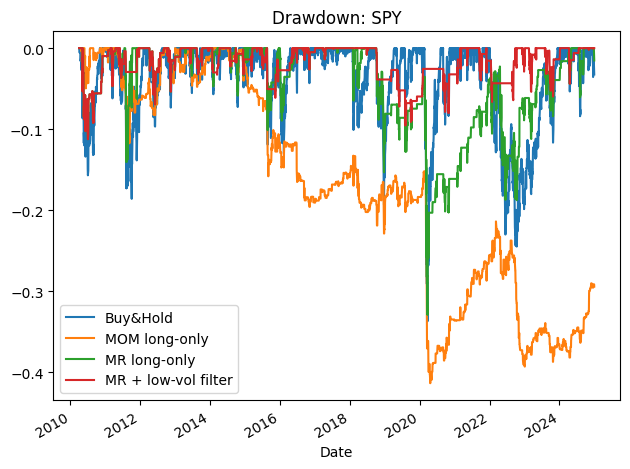

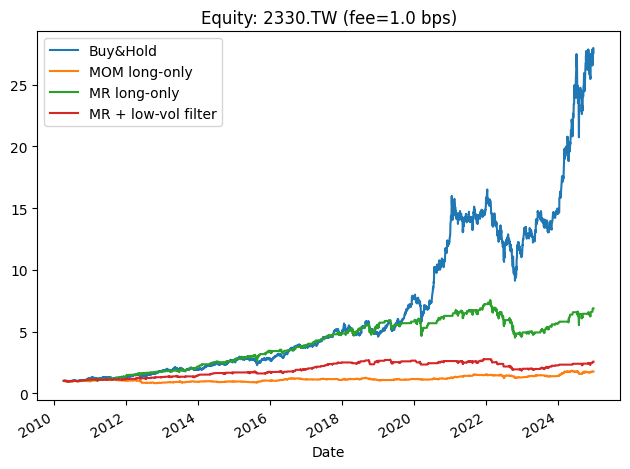

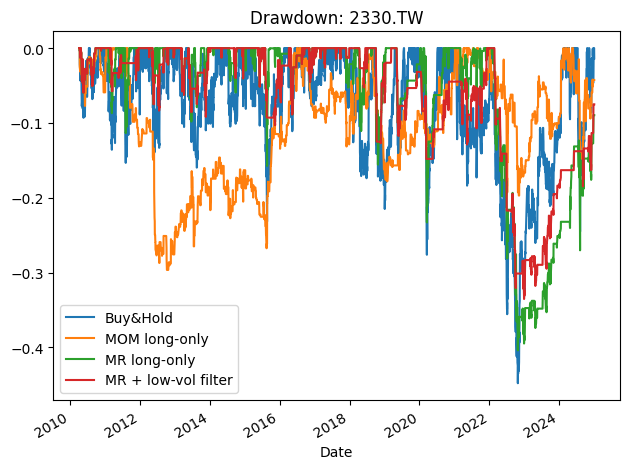

,Symbol,Strategy,FinalEquity,AnnRet,AnnVol,Sharpe,MaxDD,Calmar
0,SPY,Buy&Hold,6.572025,0.136310,0.170940,0.833429,-0.337172,0.404275
1,SPY,MOM_longonly,0.889584,-0.007909,0.090010,-0.042601,-0.413592,-0.019124
2,SPY,MR_longonly,2.614174,0.067393,0.136974,0.544897,-0.329199,0.204718
3,SPY,MR_lowvol_filter,2.197983,0.054904,0.075884,0.742264,-0.112420,0.488386
4,2330.TW,Buy&Hold,27.586594,0.262697,0.252545,1.049837,-0.447990,0.586390
5,2330.TW,MOM_longonly,1.756774,0.040415,0.133160,0.363889,-0.296563,0.136278
6,2330.TW,MR_longonly,6.880595,0.145238,0.170503,0.880576,-0.404122,0.359390
7,2330.TW,MR_lowvol_filter,2.561851,0.068382,0.118225,0.618510,-0.335449,0.203851


In [3]:
START, END = "2010-01-01", "2025-01-01"
FEE_BPS = 1.0

os.makedirs("reports/figures", exist_ok=True)

def prepare(symbol):
    df = fetch_yahoo(symbol, START, END)
    df = add_returns(df)
    df = add_momentum_signal(df, lookback=60)
    df = add_mean_reversion_signal(df, z_window=20)
    df = add_vol_regime(df, vol_window=20, q=0.7)
    df = df.dropna()
    return df

def equity_from_returns(r):
    return (1.0 + r.fillna(0.0)).cumprod()

def drawdown_from_equity(eq):
    peak = eq.cummax()
    dd = (eq - peak) / peak
    return dd

def perf_metrics(strat_ret, periods=252):
    r = strat_ret.dropna()
    eq = equity_from_returns(r)
    ann_ret = eq.iloc[-1] ** (periods / len(r)) - 1.0 if len(eq) else 0.0
    ann_vol = r.std(ddof=0) * np.sqrt(periods) if len(r) else 0.0
    sharpe = (r.mean() / r.std()) * np.sqrt(periods) if len(r) else 0.0
    dd = drawdown_from_equity(eq)
    maxdd = dd.min() if len(dd) else 0.0
    calmar = ann_ret / abs(maxdd) if maxdd else np.nan
    return {
        "FinalEquity": float(eq.iloc[-1]) if len(eq) else np.nan,
        "AnnRet": float(ann_ret),
        "AnnVol": float(ann_vol),
        "Sharpe": float(sharpe),
        "MaxDD": float(maxdd),
        "Calmar": float(calmar) if np.isfinite(calmar) else np.nan,
    }, eq, dd

def run(symbol):
    df = prepare(symbol)
    
    #baseline
    bh_ret = df["ret_1d"]
    bh_metrics, bh_eq, bh_dd = perf_metrics(bh_ret)
    
    bt_mom = backtest_long_only(df, "signal_mom", fee_bps=FEE_BPS)
    bt_mr = backtest_long_only(df, "signal_mr", fee_bps=FEE_BPS)
    bt_mr_f = backtest_long_only_with_regime(df, "signal_mr", "high_vol", regime_active=0, fee_bps=FEE_BPS)
    
    mom_metrics, mom_eq, mom_dd = perf_metrics(bt_mom["strat_ret"])
    mr_metrics, mr_eq, mr_dd = perf_metrics(bt_mr["strat_ret"])
    mrf_metrics, mrf_eq, mrf_dd = perf_metrics(bt_mr_f["strat_ret"])

    table = pd.DataFrame([
        {"Symbol": symbol, "Strategy": "Buy&Hold", **bh_metrics},
        {"Symbol": symbol, "Strategy": "MOM_longonly", **mom_metrics},
        {"Symbol": symbol, "Strategy": "MR_longonly", **mr_metrics},
        {"Symbol": symbol, "Strategy": "MR_lowvol_filter", **mrf_metrics},
    ])
    
    #Plot equity
    plt.figure()
    bh_eq.plot(label="Buy&Hold")
    mom_eq.plot(label="MOM long-only")
    mr_eq.plot(label="MR long-only")
    mrf_eq.plot(label="MR + low-vol filter")
    plt.title(f"Equity: {symbol} (fee={FEE_BPS} bps)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"reports/figures/{symbol}_equity.png", dpi=200)
    plt.show()   
    
    # Plot drawdown
    plt.figure()
    bh_dd.plot(label="Buy&Hold")
    mom_dd.plot(label="MOM long-only")
    mr_dd.plot(label="MR long-only")
    mrf_dd.plot(label="MR + low-vol filter")
    plt.title(f"Drawdown: {symbol}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"reports/figures/{symbol}_drawdown.png", dpi=200)
    plt.show()

    return table

all_tables = []
for sym in ["SPY", "2330.TW"]:
    all_tables.append(run(sym))

report = pd.concat(all_tables, ignore_index=True)
report.to_csv("reports/summary_metrics.csv", index=False)
report